# Visualizar CAMB y Simulaciones



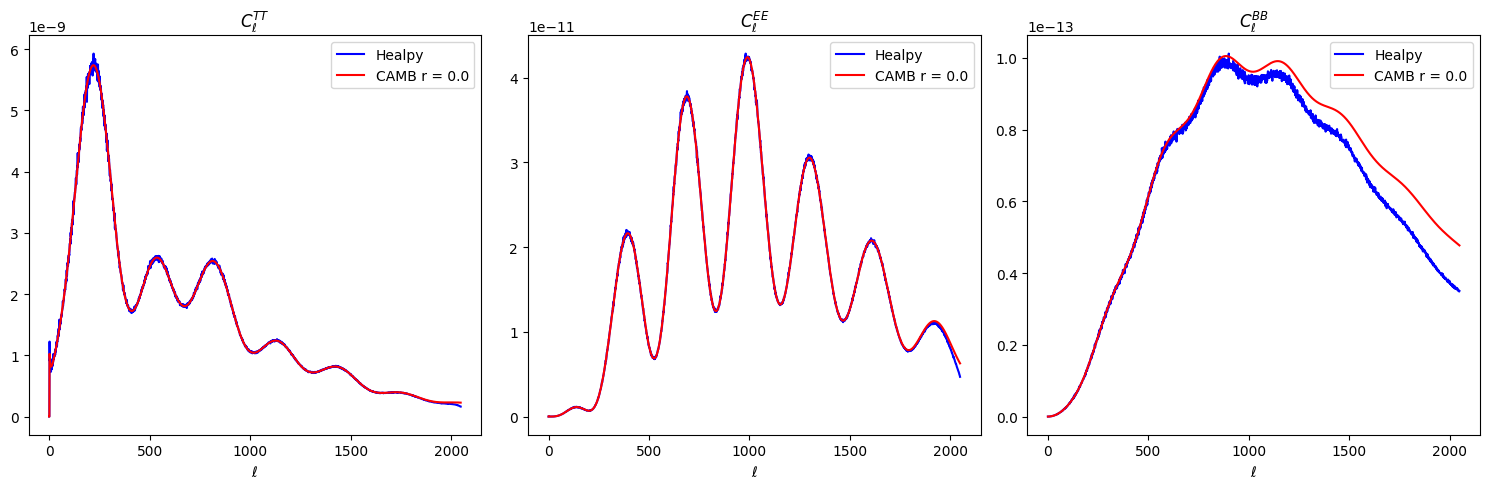

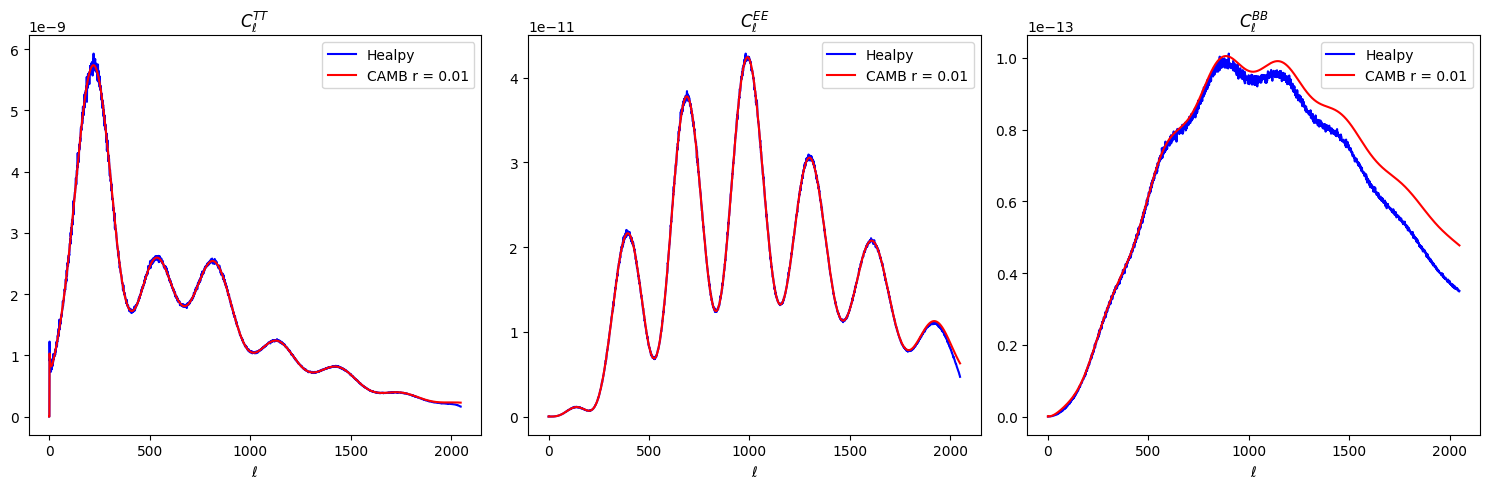

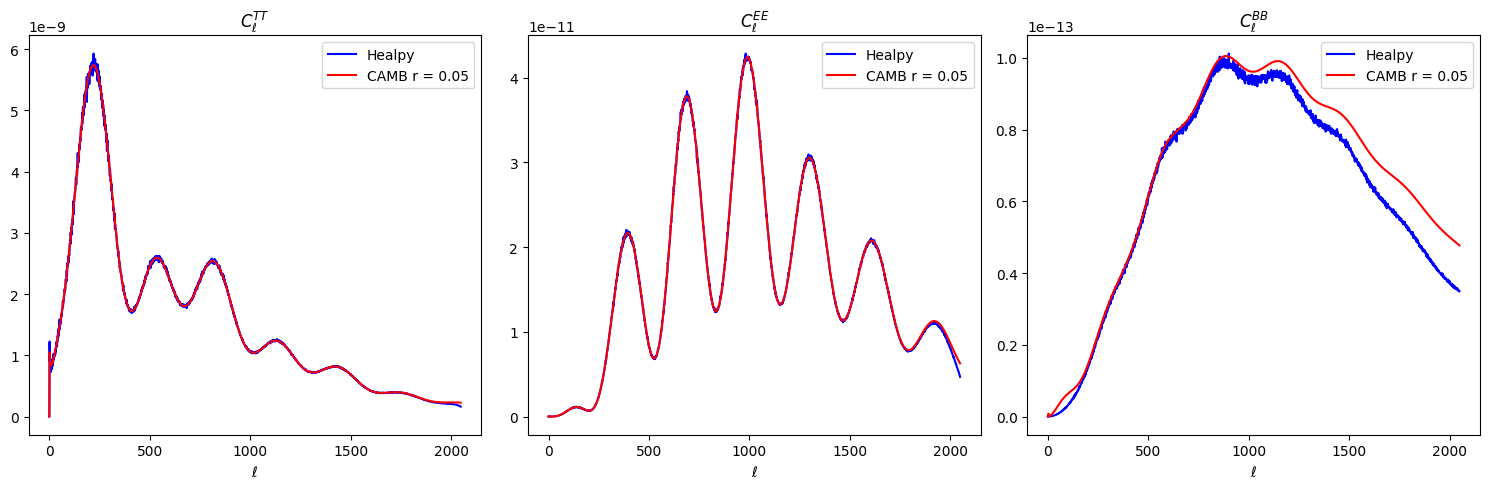

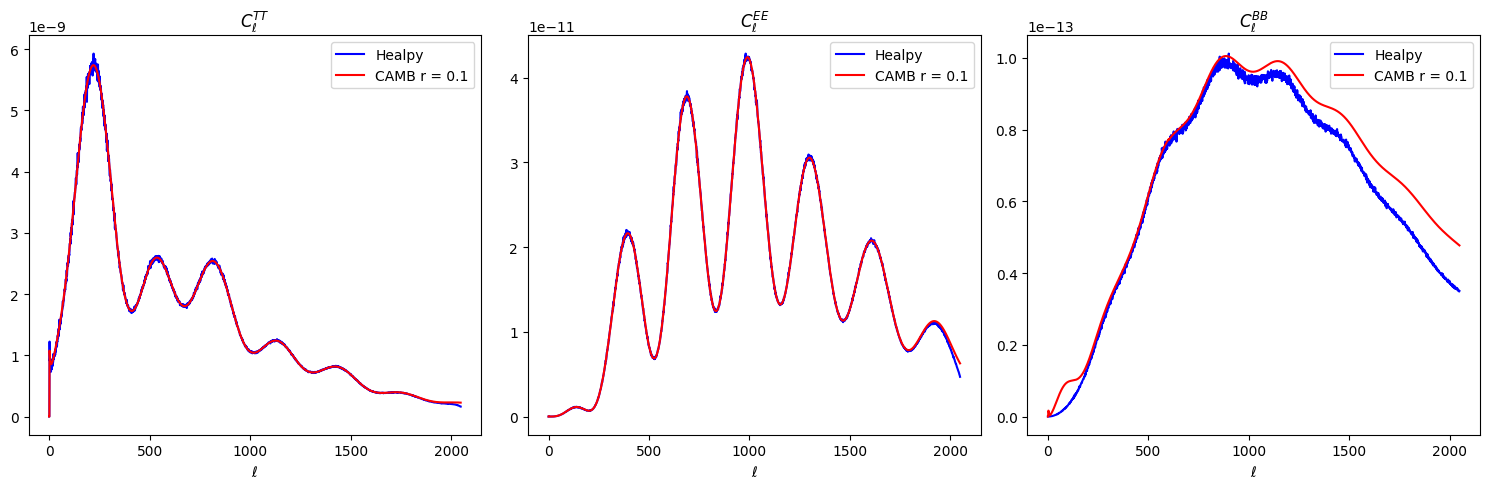

In [2]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scripts.config import NSIDE, LMAX, NSIM, BASE_SEED

# ---------------
# Ruta de los mapas
# ---------------

ruta = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/"

ruta_f = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/Foreground/"

ruta_n = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/Noise_SO"

ruta_obs = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/obs_maps"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

vect_r = np.array([0, 0.01, 0.05, 0.1])

freq = np.array([27, 39, 93, 145, 225, 280])

names = np.array(["T", "E" , "B"])

names1 = np.array(["TT", "EE", "BB", "TE"])

# Cargamos las simulaciones para cada r
for r in vect_r:
    
    ruta_r = os.path.join(ruta, f"r_{r}")

    ells = np.loadtxt(os.path.join(ruta_r, "ells.txt"))

    factor = ells*(ells+1)/(2*np.pi) # Para graficar D_l

    mean_Cl_ls = np.zeros((3, lmax+1), dtype=float)  # TT, EE, BB
    mean_Cl_ul = np.zeros((3, lmax+1), dtype=float)
    # mean_Cl_TE = 0
    for i in range(nsim):

        data = np.load(os.path.join(ruta_r, f"cmb_alms_total{i+1}.npz")) # cargar cmb_total

        data1 = np.load(os.path.join(ruta_r, f"cmb_alms_unlensed{i+1}.npz")) # cargar cmb_unlensed

        # lista de alms orden T, E y B 
        for j, name in enumerate(names):

            alm_total = data[f"alm{name}"] 

            alm_unlensed = data1[f"alm{name}"]

            mean_Cl_ls[j] += hp.sphtfunc.alm2cl(alm_total, alm_total, lmax=lmax)*factor
            mean_Cl_ul[j] += hp.sphtfunc.alm2cl(alm_unlensed, alm_unlensed, lmax=lmax)*factor


    mean_Cl_ls = mean_Cl_ls/nsim
    mean_Cl_ul = mean_Cl_ul/nsim

    Cl_total = []
    Cl_unlensed = []
    for name in names1:
        tot_cl =  np.loadtxt(os.path.join(ruta_r, f"Cl_total_{name}.txt"))
        Cl_total.append(tot_cl)
        unl_cl =  np.loadtxt(os.path.join(ruta_r, f"Cl_unlensed_{name}.txt"))
        Cl_unlensed.append(unl_cl)
    
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].plot(ells, mean_Cl_ls[0],color='b',label='Healpy') 
    ax[0].plot(ells, Cl_total[0]*factor,color="r",label=f"CAMB r = {r}")
    ax[0].set_title(r'$C_\ell^{TT}$')
    ax[0].legend()
    ax[0].set_xlabel(r'$\ell$')

    ax[1].plot(ells, mean_Cl_ls[1],color='b',label='Healpy') 
    ax[1].plot(ells, Cl_total[1]*factor,color="r",label=f"CAMB r = {r}")
    ax[1].set_title(r'$C_\ell^{EE}$')
    ax[1].legend()
    ax[1].set_xlabel(r'$\ell$')

    ax[2].plot(ells, mean_Cl_ls[2],color='b',label='Healpy') 
    ax[2].plot(ells, Cl_total[2]*factor,color="r",label=f"CAMB r = {r}")
    ax[2].set_title(r'$C_\ell^{BB}$')
    ax[2].legend()
    ax[2].set_xlabel(r'$\ell$')

    plt.tight_layout()
    plt.show()

            

# Mapas T, Q, U y $\phi$

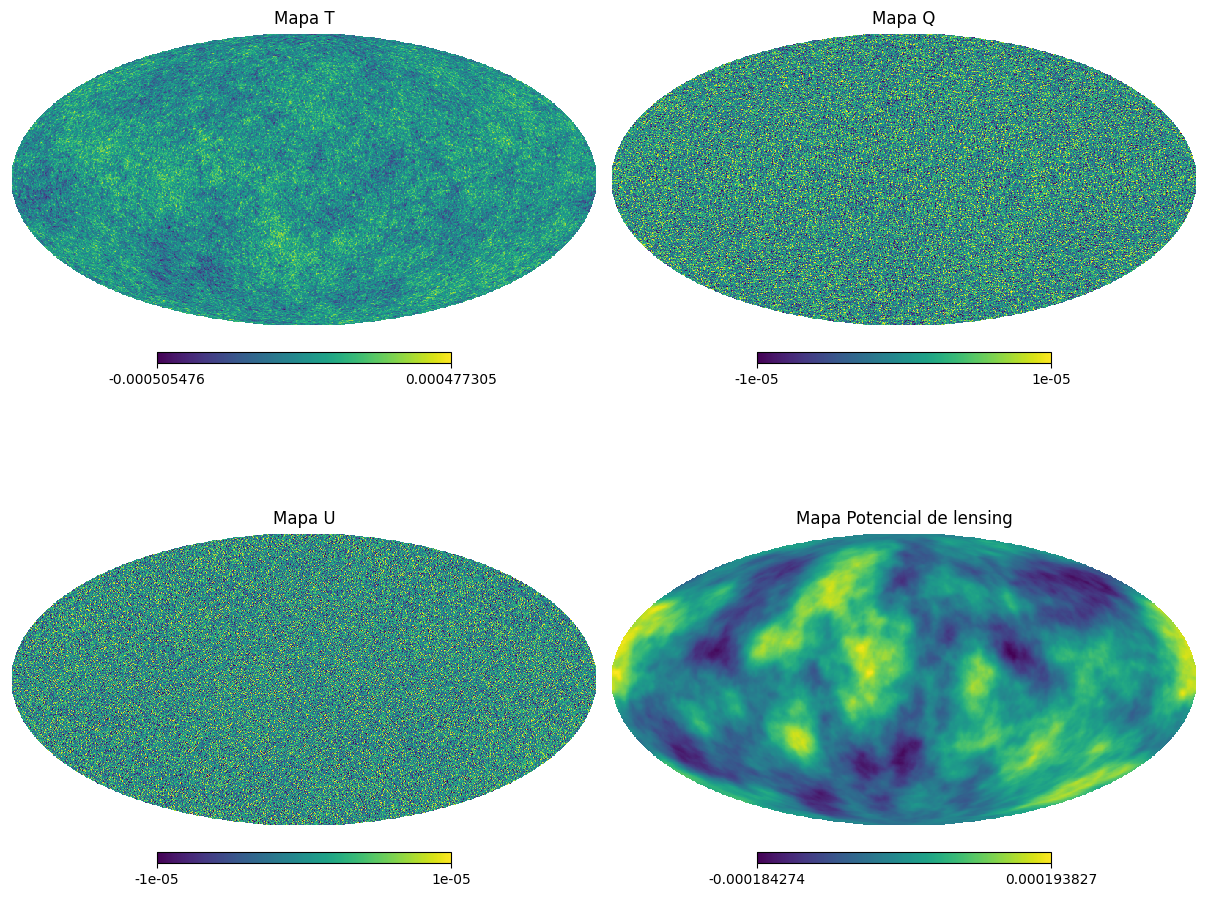

In [3]:

vect_r = np.array([0, 0.01, 0.05, 0.1])

# Modificar la ruta para mapas de otro valor de r
ruta_r = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

names = np.array(["T", "E" , "B"])

data = np.load(os.path.join(ruta_r, f"cmb_alms_total{5}.npz")) # cargar cmb_total

data1 = np.load(os.path.join(ruta_r, f"cmb_alms_unlensed{5}.npz")) # cargar cmb_unlensed

data2 = np.load(os.path.join(ruta_r, f"cmb_alms_phi{5}.npz")) # cargar phi
alm_phi = data2["alm_phi"]

alms_total = []
alms_unlensed = []
for name in names:

    alm = data[f"alm{name}"] 
    alms_total.append(alm)
    
    alm1 = data1[f"alm{name}"] 
    alms_unlensed.append(alm1)

map_total_T, map_total_Q, map_total_U = hp.alm2map(alms_total, nside=nside, lmax=lmax ,pol=True)
map_unlensed_T, map_unlensed_Q, map_unlensed_U = hp.alm2map(alms_unlensed, nside=nside, lmax=lmax, pol=True)
map_phi = hp.alm2map(alm_phi, nside=nside, lmax=lmax)

plt.figure(figsize=(12,10))

hp.mollview(map_total_T, title="Mapa T",sub=(2,2,1))
hp.mollview(map_total_Q, title="Mapa Q",min=-1e-5,max=1e-5,sub=(2,2,2))
hp.mollview(map_total_U, title="Mapa U",min=-1e-5,max=1e-5,sub=(2,2,3))
hp.mollview(map_phi, title="Mapa Potencial de lensing",sub=(2,2,4))
plt.show()


# Mapas observados 

In [ ]:

ruta_obs = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/obs_maps"

nside = 512
lmax = 1535
nsim = 20

vect_r = np.array([0, 0.01, 0.05, 0.1])

freq = np.array([27, 39, 93, 145, 225, 280])

names = np.array(["T", "E" , "B"])

names1 = np.array(["TT", "EE", "BB", "TE"])

# Mapas HILC